In [1]:
# Plotting and Data analysis
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import joblib

# sci-kit learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFECV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score

In [2]:
# df = pd.read_csv("../data/dataset.csv")
df = pd.read_csv("../data/dataset_light.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 56 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   mfcc_1_mean          500 non-null    float64
 1   mfcc_1_std           500 non-null    float64
 2   mfcc_2_mean          500 non-null    float64
 3   mfcc_2_std           500 non-null    float64
 4   mfcc_3_mean          500 non-null    float64
 5   mfcc_3_std           500 non-null    float64
 6   mfcc_4_mean          500 non-null    float64
 7   mfcc_4_std           500 non-null    float64
 8   mfcc_5_mean          500 non-null    float64
 9   mfcc_5_std           500 non-null    float64
 10  mfcc_6_mean          500 non-null    float64
 11  mfcc_6_std           500 non-null    float64
 12  mfcc_7_mean          500 non-null    float64
 13  mfcc_7_std           500 non-null    float64
 14  mfcc_8_mean          500 non-null    float64
 15  mfcc_8_std           500 non-null    flo

# Data Preprocessing

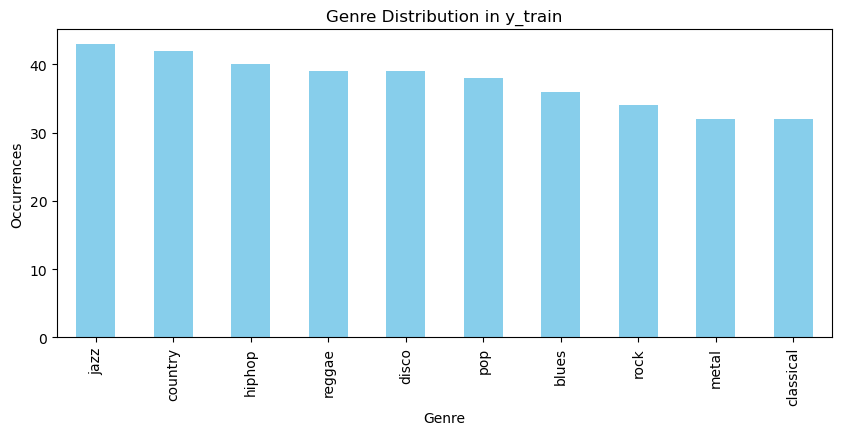

In [3]:
# Separating Train and Test sets to avoid data leakage and inconsistent preprocessing

X = df.drop(columns='genre')
y = df['genre']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

plt.figure(figsize=(10,4))
y_train.value_counts().plot(kind='bar', color='skyblue')
plt.title("Genre Distribution in y_train")
plt.xlabel("Genre")
plt.ylabel("Occurrences")
plt.show()

In [4]:
# Scaling numerical features

scaler = StandardScaler()
X_train_new = scaler.fit_transform(X_train) 
X_test_new = scaler.transform(X_test) 

joblib.dump(scaler, "../models/feature_scaler.pkl")
X_train_new = pd.DataFrame(X_train_new, columns=X.columns)
X_test_new = pd.DataFrame(X_test_new, columns=X.columns)

X_train_new.shape

(375, 55)

Explained variance ratio (no-scaled data): [0.98173581 0.01270511]
Cumulative explained variance ratio (no-scaled data) [0.98173581 0.99444093]
Explained variance ratio (scaled data): [0.20801535 0.17556203]
Cumulative explained variance ratio (scaled data) [0.20801535 0.38357738]


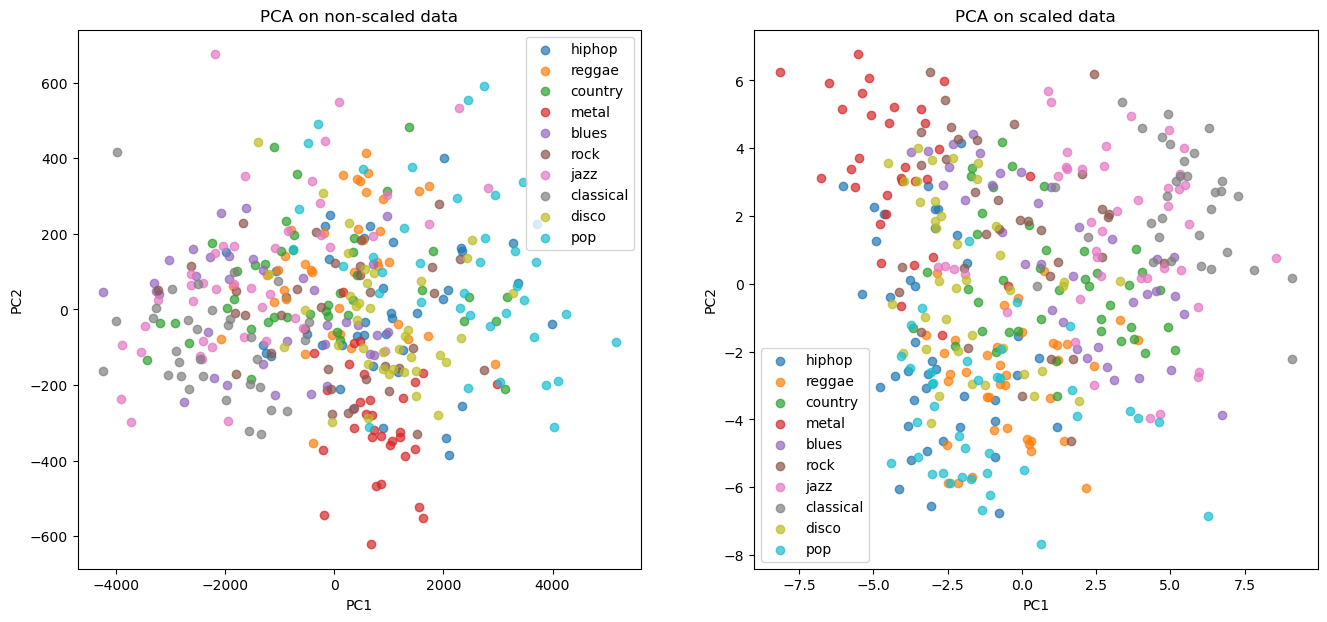

In [5]:
# Comparing PCA on non-scaled and scaled data
# This block is only made to show PCA benefits

pca_noscaled = PCA(n_components=2)
pca_scaled = PCA(n_components=2)
X_noscaled_pca = pca_noscaled.fit_transform(X_train)
X_scaled_pca = pca_scaled.fit_transform(X_train_new)

# Not tranforming test data because this block is only made to compare PCA with non-scaled and scaled data

df_noscaled = pd.DataFrame(X_noscaled_pca, columns=['PC1', 'PC2'])
df_noscaled['genre'] = y_train.values

df_scaled = pd.DataFrame(X_scaled_pca, columns=['PC1', 'PC2'])
df_scaled['genre'] = y_train.values

print("Explained variance ratio (no-scaled data):", pca_noscaled.explained_variance_ratio_)
print("Cumulative explained variance ratio (no-scaled data)", pca_noscaled.explained_variance_ratio_.cumsum())

print("Explained variance ratio (scaled data):", pca_scaled.explained_variance_ratio_)
print("Cumulative explained variance ratio (scaled data)", pca_scaled.explained_variance_ratio_.cumsum())

fig, axes = plt.subplots(1, 2, figsize=(16,7))

for g in df_noscaled['genre'].unique():
    subset = df_noscaled[df_noscaled['genre'] == g]
    axes[0].scatter(subset['PC1'], subset['PC2'], label=g, alpha=0.7)
axes[0].set_title('PCA on non-scaled data')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

for g in df_scaled['genre'].unique():
    subset = df_scaled[df_scaled['genre'] == g]
    axes[1].scatter(subset['PC1'], subset['PC2'], label=g, alpha=0.7)
axes[1].set_title('PCA on scaled data')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

plt.show()

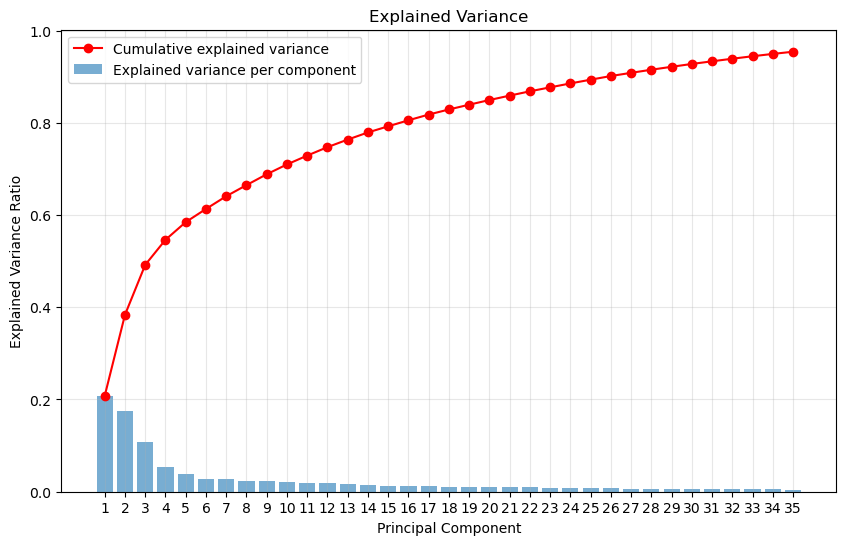

In [6]:
# Feature reduction using PCA with fixed cumulative variance

cumulative_var_th = 0.95

pca = PCA(n_components=cumulative_var_th)
X_train_pca = pca.fit_transform(X_train_new)
X_test_pca = pca.transform(pd.DataFrame(X_test_new, columns=X_train_new.columns))

df_pca = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
df_pca['genre'] = y_train.values
df_pca.to_csv('../data/dataset_pca.csv', index=False)

explained_var = pca.explained_variance_ratio_
cumulative_var = explained_var.cumsum()
components = np.arange(1, len(explained_var)+1)

plt.figure(figsize=(10,6))
plt.bar(components, explained_var, alpha=0.6, label='Explained variance per component')
plt.plot(components, cumulative_var, marker='o', color='red', label='Cumulative explained variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance')
plt.xticks(components)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [7]:
# Feature reduction rateo

print("Training set shape before PCA:", X_train.shape) 
print("Training set shape after PCA:", X_train_pca.shape) 
print("Feature reduction rateo", X_train_pca.shape[1] / X_train.shape[1]) 

Training set shape before PCA: (375, 55)
Training set shape after PCA: (375, 35)
Feature reduction rateo 0.6363636363636364


In [8]:
# Shows the 5 Most important features for each of the 10 most influent PCA components

loadings = pd.DataFrame(pca.components_, columns=X.columns)
loadings.index = [f'PC{i+1}' for i in range(loadings.shape[0])]

top_features_per_pc = {}
for pc in loadings.index[:10]:  
    top_features = loadings.loc[pc].abs().sort_values(ascending=False).head(5).index.tolist()
    top_features_per_pc[pc] = top_features

for pc, features in top_features_per_pc.items():
    print(f"{pc}: {features}")

PC1: ['contrast_3_mean', 'contrast_4_mean', 'contrast_5_mean', 'mfcc_1_mean', 'spec_centroid_mean']
PC2: ['contrast_7_mean', 'mfcc_2_std', 'mfcc_7_mean', 'mfcc_4_std', 'mfcc_6_std']
PC3: ['contrast_7_mean', 'mfcc_7_std', 'mfcc_10_std', 'mfcc_9_mean', 'mfcc_13_std']
PC4: ['zcr_mean', 'spec_centroid_mean', 'spec_rolloff_mean', 'mfcc_2_mean', 'mfcc_1_mean']
PC5: ['mfcc_14_mean', 'mfcc_15_mean', 'mfcc_13_mean', 'contrast_1_mean', 'chroma_11_mean']
PC6: ['chroma_10_mean', 'chroma_11_mean', 'chroma_6_mean', 'chroma_9_mean', 'mfcc_11_mean']
PC7: ['chroma_1_mean', 'mfcc_3_mean', 'chroma_2_mean', 'tempo', 'chroma_5_mean']
PC8: ['contrast_1_mean', 'mfcc_3_mean', 'chroma_5_mean', 'chroma_10_mean', 'chroma_1_mean']
PC9: ['chroma_9_mean', 'chroma_8_mean', 'chroma_3_mean', 'rms_mean', 'chroma_4_mean']
PC10: ['chroma_3_mean', 'chroma_1_mean', 'chroma_12_mean', 'chroma_4_mean', 'mfcc_3_std']


# Model Selection

In [9]:
# Initializing models with different parameters

models = {
    "LogisticRegression": (
        LogisticRegression(max_iter=1000, random_state=42),
        {
            "C": [0.1, 1, 10],
            "penalty": ["l2"],
            "solver": ["lbfgs"]
        }
    ),
    "SVM": (
        LinearSVC(max_iter=5000, random_state=42),
        {
            "C": [0.1, 1, 10]
        }
    ),
    "DecisionTree": (
        DecisionTreeClassifier(random_state=42),
        {
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=42),
        {
            "n_estimators": [100, 200],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5]
        }
    )
}

In [10]:
# Testing Classifiers on all features

results = []

for name, (model, param_grid) in models.items():
    print(f"%%%%%%%%%% Training {name}... %%%%%%%%%%")

    grid = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train_new, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_new)
    
    score = best_model.score(X_test_new, y_test)
    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "CV Best Score": grid.best_score_,
        "Test Accuracy": score
    })

    print(f"\n{name} results:")
    print("Best Params:", grid.best_params_)
    print("CV Best Score:", grid.best_score_)
    print("Test Accuracy:", score)
    print("Classification Report:\n", classification_report(y_test, y_pred))

results_all_df = pd.DataFrame(results)

%%%%%%%%%% Training LogisticRegression... %%%%%%%%%%

LogisticRegression results:
Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
CV Best Score: 0.6
Test Accuracy: 0.552
Classification Report:
               precision    recall  f1-score   support

       blues       0.55      0.43      0.48        14
   classical       0.80      0.67      0.73        18
     country       0.50      0.62      0.56         8
       disco       0.50      0.36      0.42        11
      hiphop       0.50      0.60      0.55        10
        jazz       0.27      0.43      0.33         7
       metal       0.83      0.83      0.83        18
         pop       0.62      0.42      0.50        12
      reggae       0.38      0.91      0.54        11
        rock       0.50      0.19      0.27        16

    accuracy                           0.55       125
   macro avg       0.55      0.55      0.52       125
weighted avg       0.59      0.55      0.54       125

%%%%%%%%%% Training SVM... %%%%%%%%%%

In [11]:
print("\n Models Comparison:")
results_all_df


 Models Comparison:


,Model,Best Params,CV Best Score,Test Accuracy
0,LogisticRegression,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.600000,0.552
1,SVM,{'C': 0.1},0.557333,0.632
2,DecisionTree,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.384000,0.344
3,RandomForest,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.592000,0.648


In [12]:
# Testing Classifiers after PCA feature reduction 

results_pca = []
predictions_pca = {}

for name, (model, param_grid) in models.items():
    print(f"%%%%%%%%%% Training {name} with PCA features... %%%%%%%%%%")

    grid = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train_pca, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_pca)
    
    predictions_pca[name] = (y_test, y_pred, best_model.classes_)
    
    score = best_model.score(X_test_pca, y_test)
    results_pca.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "CV Best Score": grid.best_score_,
        "Test Accuracy": score
    })

    print(f"\n{name} results:")
    print("Best Params:", grid.best_params_)
    print("CV Best Score:", grid.best_score_)
    print("Test Accuracy:", score)
    print("Classification Report:\n", classification_report(y_test, y_pred))

results_pca_df = pd.DataFrame(results_pca)

%%%%%%%%%% Training LogisticRegression with PCA features... %%%%%%%%%%

LogisticRegression results:
Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
CV Best Score: 0.5706666666666667
Test Accuracy: 0.544
Classification Report:
               precision    recall  f1-score   support

       blues       0.45      0.36      0.40        14
   classical       0.80      0.67      0.73        18
     country       0.31      0.50      0.38         8
       disco       0.50      0.18      0.27        11
      hiphop       0.54      0.70      0.61        10
        jazz       0.38      0.43      0.40         7
       metal       0.82      0.78      0.80        18
         pop       0.62      0.67      0.64        12
      reggae       0.45      0.91      0.61        11
        rock       0.33      0.19      0.24        16

    accuracy                           0.54       125
   macro avg       0.52      0.54      0.51       125
weighted avg       0.55      0.54      0.53       125

%%%%

In [13]:
print("\nModels comparison with PCA:")
results_pca_df


Models comparison with PCA:


,Model,Best Params,CV Best Score,Test Accuracy
0,LogisticRegression,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.570667,0.544
1,SVM,{'C': 10},0.536000,0.520
2,DecisionTree,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.352000,0.312
3,RandomForest,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.520000,0.624


In [14]:
# Testing Classifiers after RFE feature reduction 

results_rfe = []
predictions_rfe = {}

for name, (model, param_grid) in models.items():
    print(f"\n%%%%%%%%%% Feature selection + training for {name}... %%%%%%%%%%")
    
    selector = RFECV(estimator=model, step=1, cv=5, scoring="accuracy", n_jobs=-1)
    X_train_sel = selector.fit_transform(X_train_new, y_train)
    X_test_sel = selector.transform(X_test_new)
    
    print(f"{name} selected {X_train_sel.shape[1]} features")
    
    grid = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train_sel, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_sel)
    
    predictions_rfe[name] = (y_test, y_pred, best_model.classes_)
    
    score = best_model.score(X_test_sel, y_test)
    results_rfe.append({
        "Model": name,
        "Num Features": X_train_sel.shape[1],
        "Best Params": grid.best_params_,
        "CV Best Score": grid.best_score_,
        "Test Accuracy": score
    })

    print(f"\n{name} results:")
    print("Best Params:", grid.best_params_)
    print("CV Best Score:", grid.best_score_)
    print("Test Accuracy:", score)
    print("Classification Report:\n", classification_report(y_test, y_pred))

results_rfe_df = pd.DataFrame(results_rfe)


%%%%%%%%%% Feature selection + training for LogisticRegression... %%%%%%%%%%
LogisticRegression selected 20 features

LogisticRegression results:
Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
CV Best Score: 0.616
Test Accuracy: 0.528
Classification Report:
               precision    recall  f1-score   support

       blues       0.44      0.57      0.50        14
   classical       0.75      0.67      0.71        18
     country       0.40      0.50      0.44         8
       disco       0.50      0.27      0.35        11
      hiphop       0.47      0.70      0.56        10
        jazz       0.27      0.43      0.33         7
       metal       0.80      0.67      0.73        18
         pop       0.67      0.67      0.67        12
      reggae       0.40      0.55      0.46        11
        rock       0.43      0.19      0.26        16

    accuracy                           0.53       125
   macro avg       0.51      0.52      0.50       125
weighted avg       0.55  

In [15]:
print("\nModels Comparison with RFE:")
results_rfe_df


Models Comparison with RFE:


,Model,Num Features,Best Params,CV Best Score,Test Accuracy
0,LogisticRegression,20,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.616000,0.528
1,SVM,35,{'C': 1},0.621333,0.560
2,DecisionTree,55,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.384000,0.344
3,RandomForest,25,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.618667,0.584


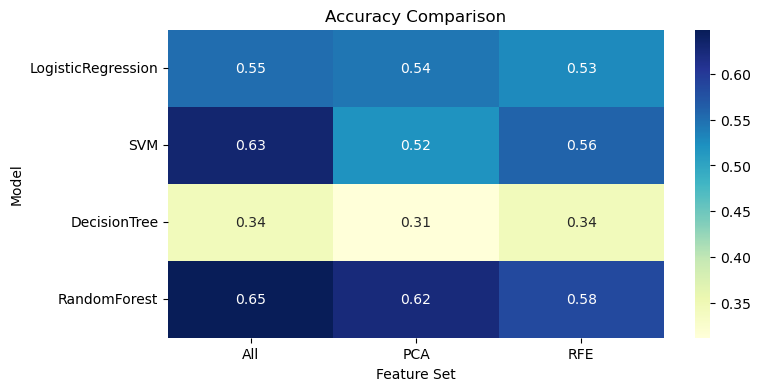

In [16]:
# Models Accuracy Comparison

results_heatmap = {
    "All": results_all_df.set_index("Model")["Test Accuracy"],
    "PCA": results_pca_df.set_index("Model")["Test Accuracy"],
    "RFE": results_rfe_df.set_index("Model")["Test Accuracy"]
}

df_results_heatmap = pd.DataFrame(results_heatmap)

plt.figure(figsize=(8,4))
sns.heatmap(df_results_heatmap, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Accuracy Comparison")
plt.xlabel("Feature Set")
plt.ylabel("Model")
plt.show()

# RandomForest Optimization

In [17]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Features Selection with RFE
selector = RFECV(
    estimator=rf,
    step=1,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

X_train_sel = selector.fit_transform(X_train_new, y_train)
X_test_sel = selector.transform(X_test_new)

print(f"RFECV selected {X_train_sel.shape[1]} features")

# Optimization with GridSearch on different metrics
param_grid = {
    "n_estimators": [100, 500, 1000],
    "max_depth": [None, 20, 50],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

scoring = {
    "Accuracy": "accuracy",
    "F1_macro": "f1_macro",
    "Precision_macro": "precision_macro",
    "Recall_macro": "recall_macro"
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring=scoring,
    refit="Accuracy",   
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_sel, y_train)

# Best Model Performances
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_sel)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
prec = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")

# Saving Best Model
joblib.dump(best_model, "../models/rf_optimized.pkl")
print("\nBest model saved as 'rf_optimized.pkl'")
joblib.dump(selector, "../models/rfe_selector.pkl")
print("\nRFE saved as 'rfe_selector.pkl'")

results_rf = [{
    "Model": "RandomForest",
    "Num Features": X_train_sel.shape[1],
    "Best Params": grid.best_params_,
    "CV Best Accuracy": grid.cv_results_["mean_test_Accuracy"][grid.best_index_],
    "CV Best F1_macro": grid.cv_results_["mean_test_F1_macro"][grid.best_index_],
    "Test Accuracy": acc,
    "Test F1_macro": f1,
    "Test Precision_macro": prec,
    "Test Recall_macro": rec
}]

results_rf_df = pd.DataFrame(results_rf)
print("\nRandomForest Results:")
print(results_rf_df)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

report_df.to_csv("../data/rf_classification_report.csv", index=True)


RFECV selected 25 features
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best model saved as 'rf_optimized.pkl'

RFE saved as 'rfe_selector.pkl'

RandomForest Results:
          Model  Num Features  \
0  RandomForest            25   

                                         Best Params  CV Best Accuracy  \
0  {'bootstrap': True, 'max_depth': None, 'max_fe...          0.629333   

   CV Best F1_macro  Test Accuracy  Test F1_macro  Test Precision_macro  \
0          0.622812          0.608       0.575937              0.633376   

   Test Recall_macro  
0           0.581439  

Classification Report:
               precision    recall  f1-score   support

       blues       0.50      0.57      0.53        14
   classical       1.00      0.78      0.88        18
     country       0.30      0.38      0.33         8
       disco       0.62      0.45      0.53        11
      hiphop       0.71      0.50      0.59        10
        jazz       0.21      0.43      0.29       

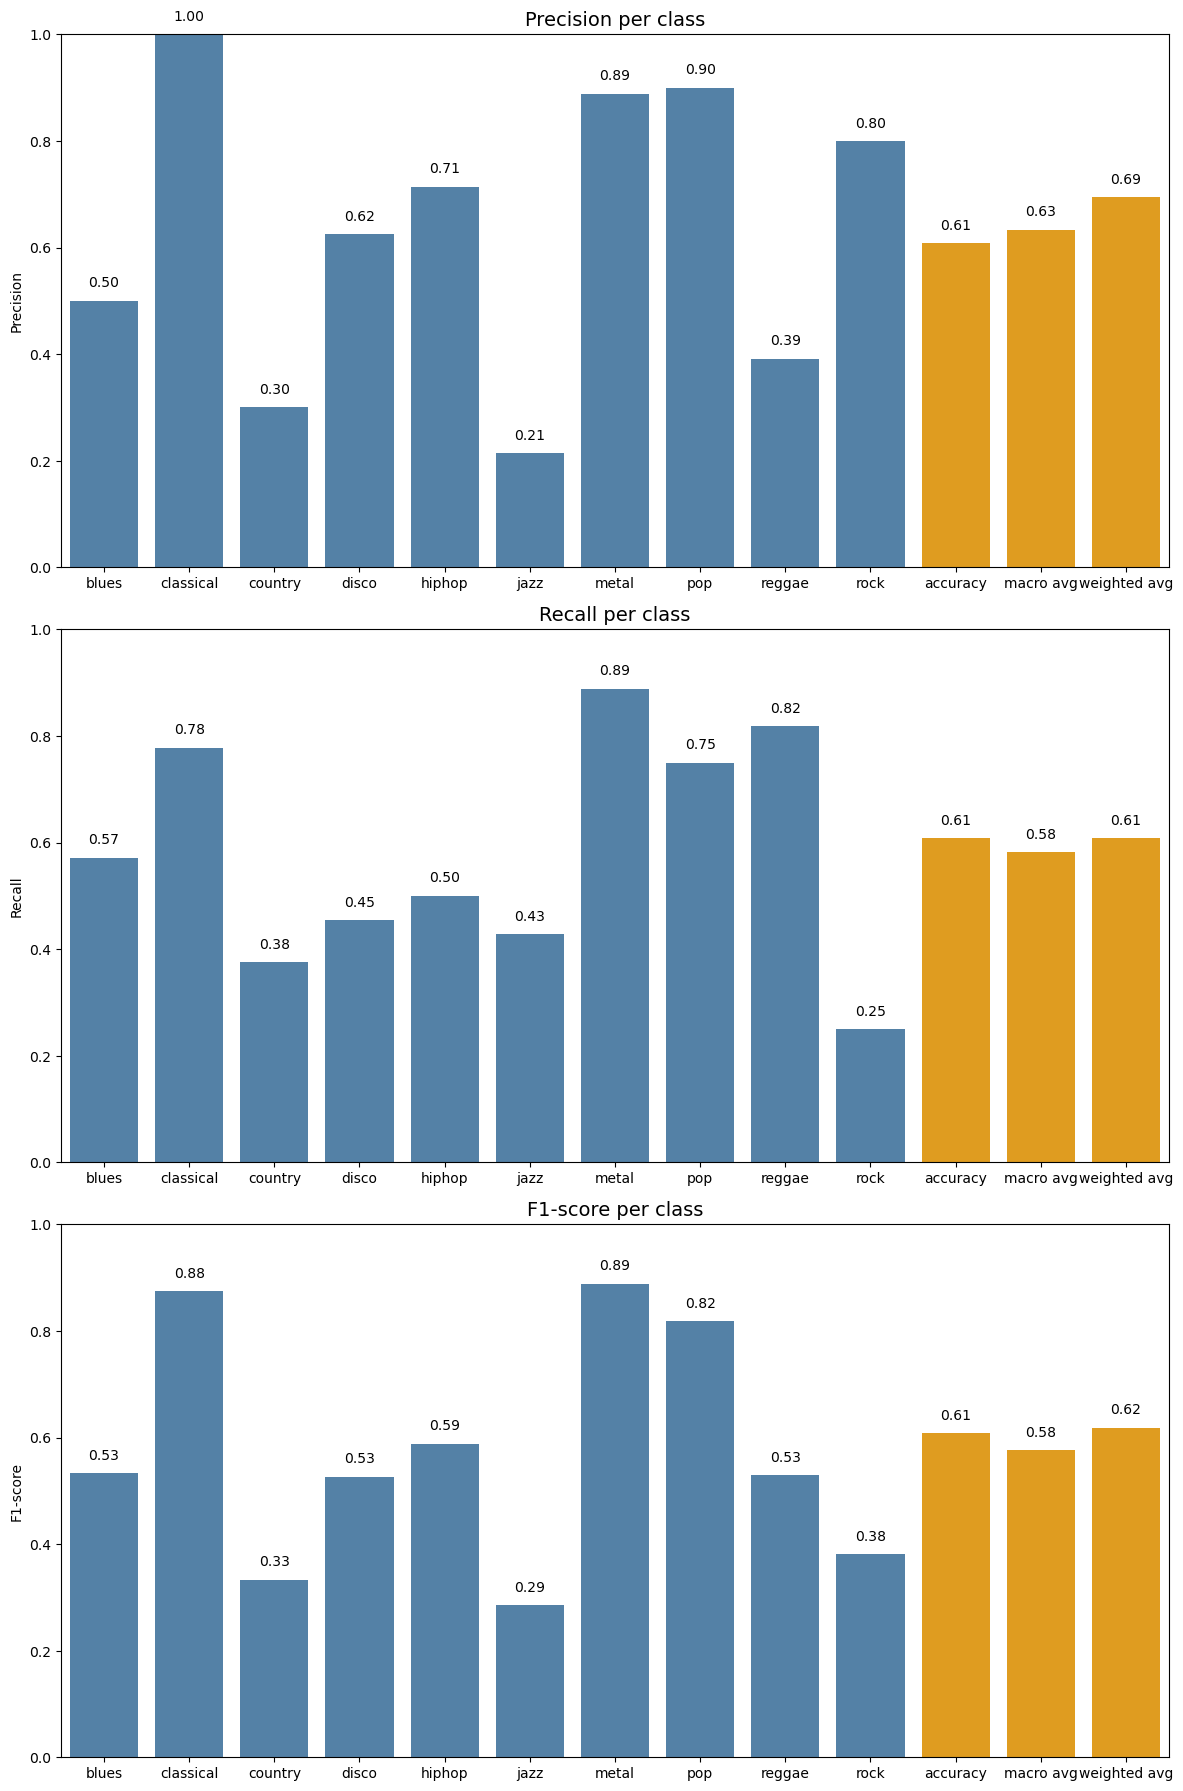

In [18]:
# Evaluation Metrics

report_df = pd.read_csv("../data/rf_classification_report.csv", index_col=0)

# Identify aggregate rows
agg_rows = ["accuracy", "macro avg", "weighted avg"]
report_df["is_aggregate"] = report_df.index.isin(agg_rows)

# Metrics to plot
metrics = ["precision", "recall", "f1-score"]
plt.figure(figsize=(12, 18))

for i, metric in enumerate(metrics, 1):
    plt.subplot(3, 1, i)
    
    # Use hue for coloring aggregate rows
    sns.barplot(
        x=report_df.index,
        y=report_df[metric],
        hue=report_df["is_aggregate"],
        palette={False: "steelblue", True: "orange"},
        dodge=False,
        legend=False
    )
    
    plt.title(f"{metric.capitalize()} per class", fontsize=14)
    plt.ylim(0, 1)
    
    # Annotate values on top of bars
    for idx, val in enumerate(report_df[metric]):
        plt.text(idx, val + 0.02, f"{val:.2f}", ha='center', va='bottom', fontsize=10)
    
    plt.xlabel("")
    plt.ylabel(metric.capitalize())

plt.tight_layout()
plt.show()

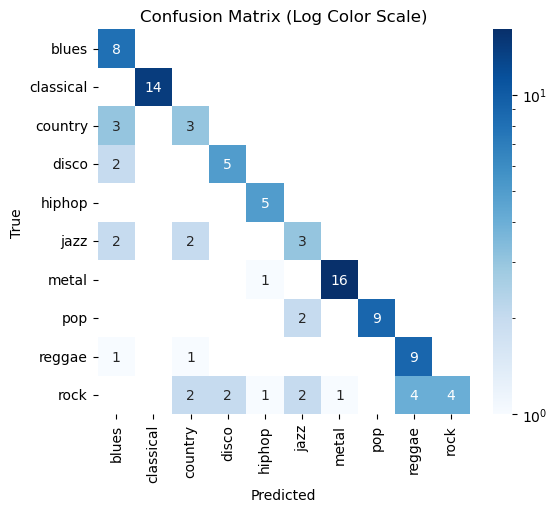

In [19]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
cm_lower = np.tril(cm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lower, annot=True, fmt="d", cmap="Blues", norm=LogNorm(),
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Log Color Scale)")
plt.show()

Selected Features:  ['mfcc_1_mean' 'mfcc_1_std' 'mfcc_2_mean' 'mfcc_3_mean' 'mfcc_3_std'
 'mfcc_4_mean' 'mfcc_4_std' 'mfcc_5_std' 'mfcc_6_mean' 'mfcc_6_std'
 'mfcc_7_std' 'mfcc_8_mean' 'mfcc_9_mean' 'mfcc_13_mean' 'contrast_1_mean'
 'contrast_3_mean' 'contrast_4_mean' 'contrast_5_mean' 'contrast_6_mean'
 'contrast_7_mean' 'spec_centroid_mean' 'spec_bandwidth_mean'
 'spec_rolloff_mean' 'zcr_mean' 'rms_mean']


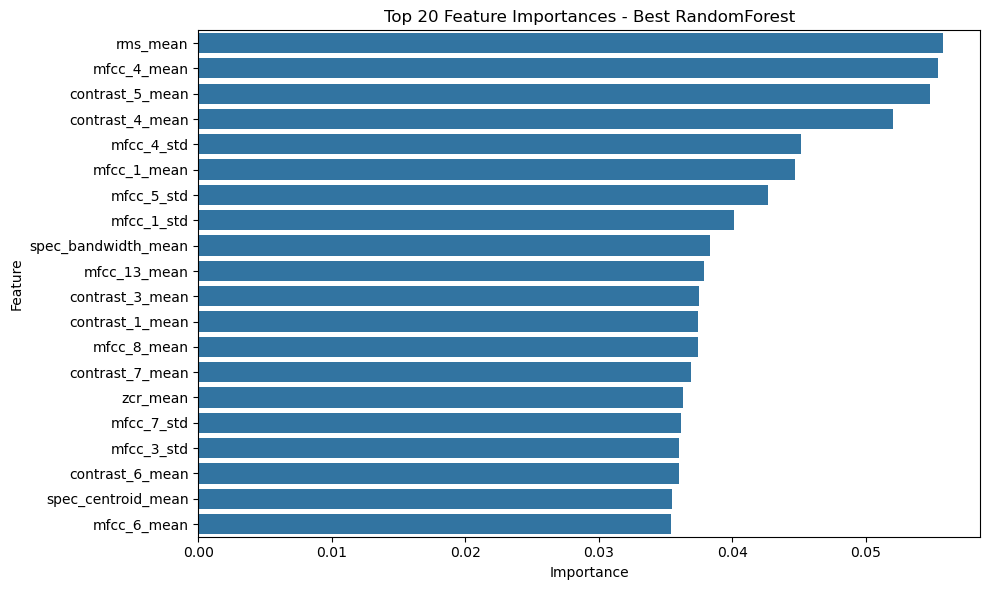

In [20]:
# Feature Importance

importances = best_model.feature_importances_
feature_names = selector.get_feature_names_out()

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("Selected Features: ", feature_names)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feat_imp.head(20))
plt.title("Top 20 Feature Importances - Best RandomForest")
plt.tight_layout()
plt.show()